# Malware Detection using Machine Learning

##importing libraries

In [1]:
import pandas as pd

## Data Loading and Initial Inspection

##describing the dataset

In [2]:
dm = pd.read_csv("/content/DynamicMalwareMatrix2.csv")

In [3]:
dm

,labels,00,0000,0000000,000000000046,00021401,00c04fc295ee,01,0156250,02,...,windowsruntime,winevt,wmiprvse,working,wow6432node,write,writefile,xaml,xls,zip
0,1,11,0,5,0,0,0,1,6,0,...,0.0,0.0,0.0,36.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,0,0,1,0,0,0,0,0,0,...,0.0,0.0,0.0,19.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,0,0,0,0,0,0,0,3,0,...,0.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,52,0,2,0,0,0,2,0,6,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2043,1,2,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0
2044,1,0,0,4,0,0,0,0,4,0,...,0.0,0.0,0.0,29.0,0.0,1.0,0.0,0.0,0.0,0.0
2045,1,0,0,2,0,0,0,0,1,0,...,0.0,0.0,1.0,33.0,0.0,1.0,0.0,0.0,0.0,0.0
2046,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0


In [4]:
dm.size

1026048

In [5]:
dm.shape

(2048, 501)

In [6]:
dm.head(10)

,labels,00,0000,0000000,000000000046,00021401,00c04fc295ee,01,0156250,02,...,windowsruntime,winevt,wmiprvse,working,wow6432node,write,writefile,xaml,xls,zip
0,1,11,0,5,0,0,0,1,6,0,...,0.0,0.0,0.0,36.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,0,0,1,0,0,0,0,0,0,...,0.0,0.0,0.0,19.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,0,0,0,0,0,0,0,3,0,...,0.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,52,0,2,0,0,0,2,0,6,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1,13,0,0,0,0,0,1,0,0,...,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0


In [7]:
dm.tail()

,labels,00,0000,0000000,000000000046,00021401,00c04fc295ee,01,0156250,02,...,windowsruntime,winevt,wmiprvse,working,wow6432node,write,writefile,xaml,xls,zip
2043,1,2,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0
2044,1,0,0,4,0,0,0,0,4,0,...,0.0,0.0,0.0,29.0,0.0,1.0,0.0,0.0,0.0,0.0
2045,1,0,0,2,0,0,0,0,1,0,...,0.0,0.0,1.0,33.0,0.0,1.0,0.0,0.0,0.0,0.0
2046,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
2047,1,0,0,0,0,0,0,0,0,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
dm.sample()

,labels,00,0000,0000000,000000000046,00021401,00c04fc295ee,01,0156250,02,...,windowsruntime,winevt,wmiprvse,working,wow6432node,write,writefile,xaml,xls,zip
1404,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0


In [9]:
dm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2048 entries, 0 to 2047
Columns: 501 entries, labels to zip
dtypes: float64(420), int64(81)
memory usage: 7.8 MB


In [10]:
dm.isnull().sum()

,0
labels,0
00,0
0000,0
0000000,0
000000000046,0
...,...
write,1
writefile,1
xaml,1
xls,1


In [11]:
dm.describe()

,labels,00,0000,0000000,000000000046,00021401,00c04fc295ee,01,0156250,02,...,windowsruntime,winevt,wmiprvse,working,wow6432node,write,writefile,xaml,xls,zip
count,2048.0,2048.00000,2048.000000,2048.000000,2048.000000,2048.000000,2048.0,2048.000000,2048.000000,2048.00000,...,2047.0,2047.000000,2047.000000,2047.000000,2047.000000,2047.000000,2047.000000,2047.000000,2047.0,2047.000000
mean,1.0,3.42627,0.183594,0.079590,0.061035,0.039551,0.0,1.057617,0.060059,1.62207,...,0.0,0.417684,0.956522,0.610650,0.009282,2.226185,0.253053,0.090376,0.0,0.982413
std,0.0,12.37200,1.931531,0.593906,0.778111,0.638221,0.0,7.068760,0.479992,8.77687,...,0.0,3.563135,4.623198,4.712698,0.398447,2.598620,1.710030,1.586582,0.0,4.422868
min,1.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.00000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,1.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.00000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
50%,1.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.00000,...,0.0,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.0,0.000000
75%,1.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.00000,...,0.0,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.0,0.000000
max,1.0,76.00000,42.000000,12.000000,21.000000,17.000000,0.0,53.000000,6.000000,54.00000,...,0.0,48.000000,50.000000,50.000000,18.000000,20.000000,26.000000,40.000000,0.0,56.000000


## Data Exploration

In [12]:
dm['labels'].value_counts()

,count
labels,
1,2048


In [34]:
y.unique()

array([1])

In [13]:
X=dm.drop('labels',axis=1)
y=dm['labels']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

## Modeling - Decision Tree Classifier

Modeling

In [14]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train,y_train)
Y_pred = model.predict(X_test)

In [48]:
import joblib
joblib.dump(model, "malware_model.pkl")

['malware_model.pkl']

In [49]:
import os
print(os.listdir('/content'))

['.config', 'DynamicMalwareMatrix2.csv', 'malware_model.pkl', 'sample_data']


In [15]:
y

,labels
0,1
1,1
2,1
3,1
4,1
...,...
2043,1
2044,1
2045,1
2046,1


In [16]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, Y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 1.00


## Modeling - Random Forest Classifier

In [17]:
from sklearn.ensemble import RandomForestClassifier

dm = RandomForestClassifier()
dm.fit(X_train, y_train)

Y_pred = dm.predict(X_test)

## Model Evaluation Metrics

In [18]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [19]:
accuracy = accuracy_score(y_test, Y_pred)
print("Accuracy =", accuracy)

Accuracy = 1.0


In [20]:
cm = confusion_matrix(y_test, Y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[512]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Unique values in synthetic labels: [0 1]
Value counts for synthetic labels:
labels
0    1024
1    1024
Name: count, dtype: int64

Confusion Matrix with Synthetic Binary Labels:
[[136 120]
 [142 114]]


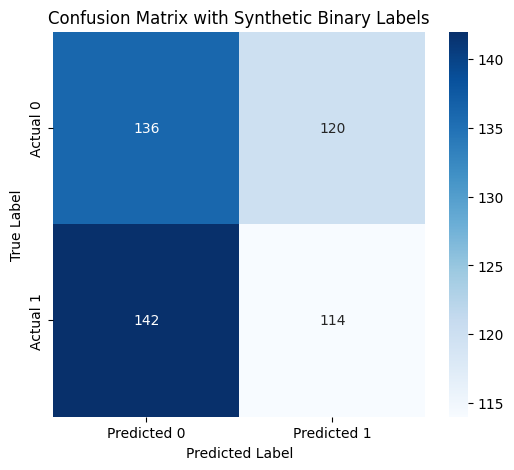


Metrics for Synthetic Binary Model:
Precision: 0.49
Recall: 0.45
F1 Score: 0.47


In [40]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Create a synthetic binary target variable from the existing 'y'
# We'll randomly change approximately half of the '1's to '0's
y_synthetic = y.copy()
num_zeros = len(y_synthetic) // 2
zero_indices = np.random.choice(y_synthetic.index, num_zeros, replace=False)
y_synthetic.loc[zero_indices] = 0

print("Unique values in synthetic labels:", y_synthetic.unique())
print("Value counts for synthetic labels:")
print(y_synthetic.value_counts())

# Split the data using the synthetic labels
X_train_synth, X_test_synth, y_train_synth, y_test_synth = train_test_split(X, y_synthetic, random_state=42, stratify=y_synthetic)

# Re-initialize and train a new Random Forest Classifier with synthetic labels
model_binary = RandomForestClassifier(random_state=42)
model_binary.fit(X_train_synth, y_train_synth)

# Make predictions
Y_pred_synth = model_binary.predict(X_test_synth)

# Generate the confusion matrix with synthetic labels
cm_binary = confusion_matrix(y_test_synth, Y_pred_synth)
print("\nConfusion Matrix with Synthetic Binary Labels:")
print(cm_binary)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_binary, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix with Synthetic Binary Labels")
plt.show()

# Calculate and print additional metrics for the synthetic binary model
precision_synth = precision_score(y_test_synth, Y_pred_synth)
recall_synth = recall_score(y_test_synth, Y_pred_synth)
f1_synth = f1_score(y_test_synth, Y_pred_synth)

print(f"\nMetrics for Synthetic Binary Model:")
print(f"Precision: {precision_synth:.2f}")
print(f"Recall: {recall_synth:.2f}")
print(f"F1 Score: {f1_synth:.2f}")

In [45]:
from sklearn.metrics import classification_report

report = classification_report(y_test_synth, Y_pred_synth)
print("\nClassification Report for Synthetic Binary Model:")
print(report)


Classification Report for Synthetic Binary Model:
              precision    recall  f1-score   support

           0       0.49      0.53      0.51       256
           1       0.49      0.45      0.47       256

    accuracy                           0.49       512
   macro avg       0.49      0.49      0.49       512
weighted avg       0.49      0.49      0.49       512



## Clustering Analysis - K-Means

### Elbow Method to Determine Optimal K

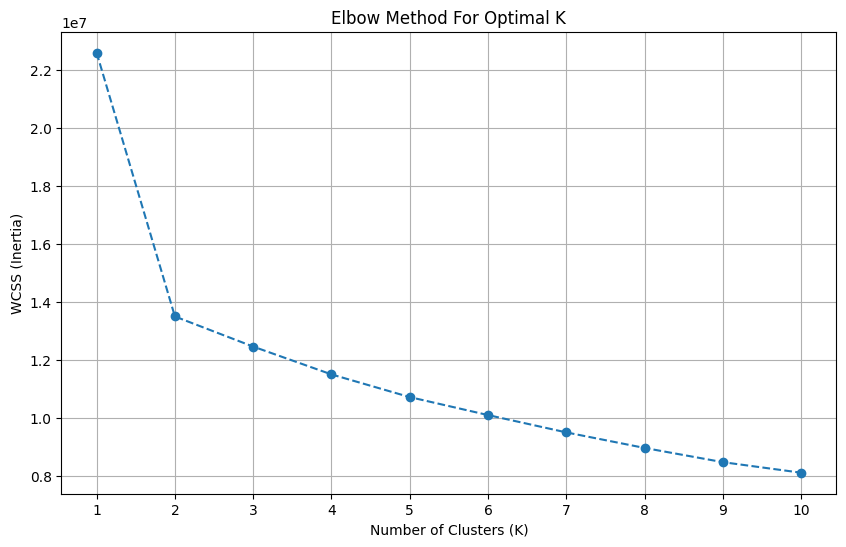

In [28]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Handle missing values in X before clustering
# For simplicity, we'll fill NaN with 0, but a more sophisticated imputation might be needed depending on the data.
X_cleaned = X.fillna(0)

wcss = [] # Within-Cluster Sum of Squares

# Try different numbers of clusters from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_cleaned)
    wcss.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

### Performing K-Means Clustering

Optimal K for K-Means: 3

First 5 rows of clustered data:
   00  0000  0000000  000000000046  00021401  00c04fc295ee  01  0156250  02  \
0  11     0        5             0         0             0   1        6   0   
1   0     0        1             0         0             0   0        0   0   
2   0     0        0             0         0             0   0        3   0   
3  52     0        2             0         0             0   2        0   6   
4   0     0        0             0         0             0   0        0   0   

   03  ...  wmiprvse  working  wow6432node  write  writefile  xaml  xls  zip  \
0   0  ...       0.0     36.0          0.0    0.0        0.0   0.0  0.0  0.0   
1   0  ...       0.0     19.0          0.0    0.0        0.0   0.0  0.0  0.0   
2   0  ...       0.0      8.0          0.0    0.0        0.0   0.0  0.0  0.0   
3   2  ...       0.0      0.0          0.0    1.0        0.0   0.0  0.0  0.0   
4   0  ...       0.0      0.0          0.0    0.0        0.0   0.0 

/tmp/ipykernel_4928/3763372137.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cluster_label', data=dm_clustered, palette='viridis')


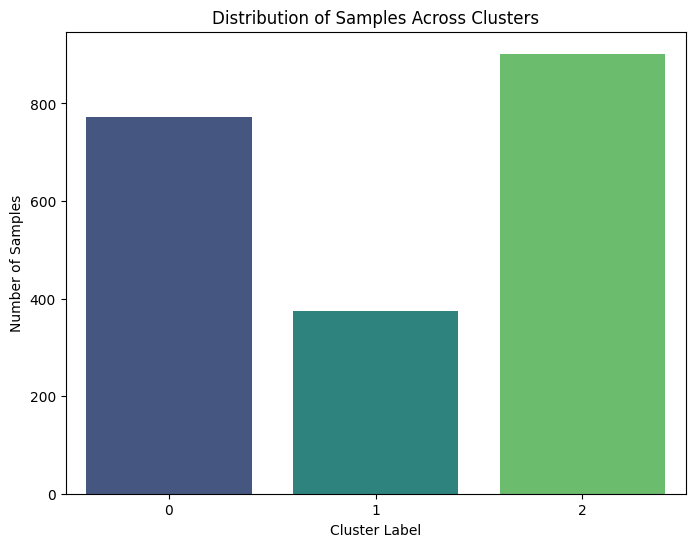

In [43]:
# Based on the elbow plot, choose an optimal K (e.g., 3 or 4 based on a typical elbow shape)
# For demonstration, let's assume K=3 (adjust based on your plot's elbow point)
optimal_k = 3 # You might need to change this after observing the elbow plot

kmeans_model = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans_model.fit_predict(X_cleaned)

# Create a new DataFrame for clustered data from X_cleaned
dm_clustered = X_cleaned.copy()
# Add the cluster labels
dm_clustered['cluster_label'] = clusters
# Add the original labels for comparison, ensuring indices align
dm_clustered['original_label'] = y.reset_index(drop=True) # Use reset_index to align with X_cleaned if original indices differ

print(f"Optimal K for K-Means: {optimal_k}")
print("\nFirst 5 rows of clustered data:")
print(dm_clustered.head())

print("\nValue counts for cluster labels:")
print(dm_clustered['cluster_label'].value_counts())

# Plotting the cluster distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='cluster_label', data=dm_clustered, palette='viridis')
plt.title('Distribution of Samples Across Clusters')
plt.xlabel('Cluster Label')
plt.ylabel('Number of Samples')
plt.show()